In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('./Data/global_cancer_patients_2015_2024 (1).csv')
df.head(5)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [3]:
pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-18', '19-35', '36-50', '51-65', '66+'])

0          66+
1        19-35
2          66+
3        36-50
4        36-50
         ...  
49995      66+
49996    36-50
49997      66+
49998    19-35
49999    19-35
Name: Age, Length: 50000, dtype: category
Categories (5, str): ['0-18' < '19-35' < '36-50' < '51-65' < '66+']

In [13]:
df.groupby(['Age', 'Gender'])['Treatment_Cost_USD'].mean().reset_index()

,Age,Gender,Treatment_Cost_USD
0,20,Female,51945.796364
1,20,Male,50991.243009
2,20,Other,53055.754756
3,21,Female,53203.180667
4,21,Male,51825.477576
...,...,...,...
205,88,Male,56031.613625
206,88,Other,54490.681548
207,89,Female,52447.012773
208,89,Male,50075.952412


<Axes: xlabel='Age', ylabel='Treatment_Cost_USD'>

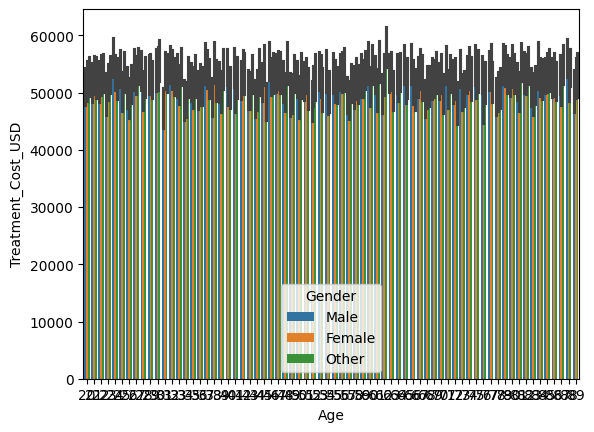

In [31]:
plt.Figure(figsize=(10, 6))
sns.barplot(x='Age', y='Treatment_Cost_USD', hue='Gender', data=df)

<Axes: xlabel='Age', ylabel='Treatment_Cost_USD'>

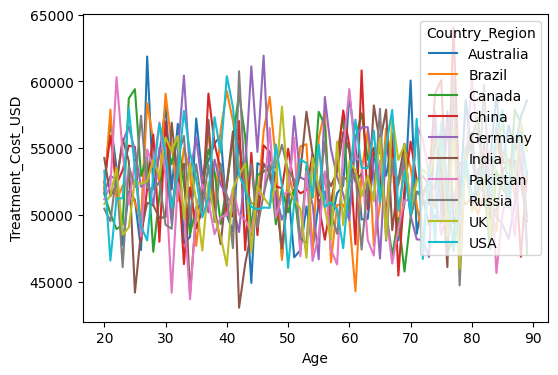

In [23]:
country_age_cost = df.groupby(['Country_Region', 'Age'])['Treatment_Cost_USD'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.lineplot(x='Age', y='Treatment_Cost_USD', hue='Country_Region', data=country_age_cost)


In [27]:
country_age_cost = df.groupby(['Country_Region', 'Age'])['Treatment_Cost_USD'].mean().reset_index()
heatmap = country_age_cost.pivot(index='Age', columns='Country_Region', values='Treatment_Cost_USD')

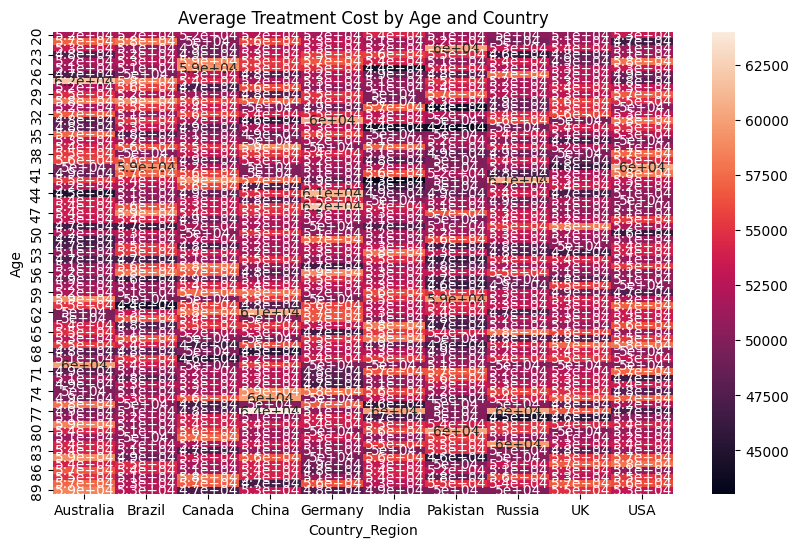

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, annot=True)
plt.title('Average Treatment Cost by Age and Country')
plt.show()

In [33]:
from scipy.stats import pearsonr, spearmanr

x = df["Treatment_Cost_USD"]
y = df["Survival_Years"]

pear_corr, pear_p = pearsonr(x, y)
spear_corr, spear_p = spearmanr(x, y)

alpha_value = 0.05

def correlation(c, p, method):
    print(f"{method} correlation coefficient: {c:.4f}")
    print(f"{method} p-value: {p:.4f}")
    
    if p < alpha_value:
        print(f"{method}: Reject the null hypothesis (significant correlation)\n")
    else:
        print(f"{method}: Fail to reject the null hypothesis (not significant)\n")

# Call the function
correlation(pear_corr, pear_p, "Pearson")
correlation(spear_corr, spear_p, "Spearman")


Pearson correlation coefficient: -0.0004
Pearson p-value: 0.9235
Pearson: Fail to reject the null hypothesis (not significant)

Spearman correlation coefficient: -0.0004
Spearman p-value: 0.9207
Spearman: Fail to reject the null hypothesis (not significant)



<Axes: xlabel='Treatment_Cost_USD', ylabel='Survival_Years'>

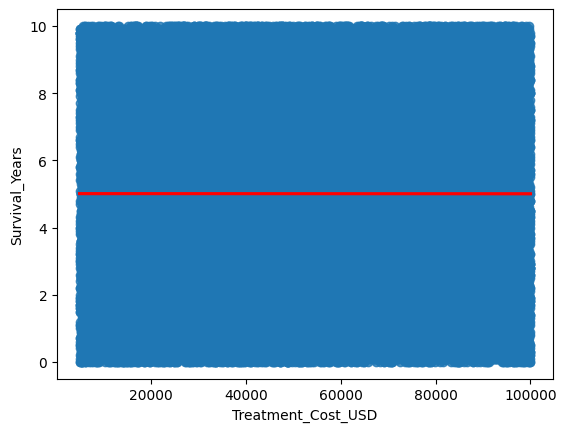

In [38]:
sns.regplot(data = df,x='Treatment_Cost_USD', y='Survival_Years', line_kws={'color': 'red'})